In [1]:
import vtuIO
import matplotlib.pyplot as plt
import os
from pathlib import Path
import numpy as np

os.chdir(Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out")))
np.set_printoptions(precision=10)

In [2]:
import Mesh_settings

ey = Mesh_settings.ey
bottom = - Mesh_settings.lz 
initial_GWT = - Mesh_settings.initial_GWT_depth
delta_time = Mesh_settings.delta_time
mid_point = round(bottom/2)

if ey == 1: #2D
    dim = 2
    ax = 1
    points = {"pt0": (0, 0), "pt1": (0, mid_point),"pt2": (0, bottom)} #"pt3" :(0,-3)
else:       #3D
    dim = 3
    ax = 2
    points = {"pt0": (0, 0,0), "pt1": (0, 0, mid_point),"pt2": (0, 0, bottom)}


pvdfile = vtuIO.PVDIO("uplift.pvd", dim=dim, interpolation_backend="scipy")
time = pvdfile.timesteps

Here we plot the time series.

In [3]:
displacement_linear = pvdfile.read_time_series("displacement", points)
#displacement_nearest = pvdfile.read_time_series("displacement", points, interpolation_method="nearest")

Here we plot the graphs.

Text(0, 0.5, 'Accumulated Displacement (m)')

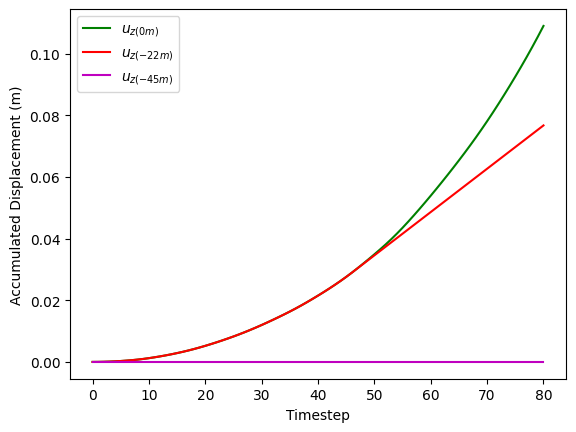

In [4]:
plt.plot(time, displacement_linear["pt0"][:,ax], "g-", label="$u_{z(" + str(points["pt0"][ax]) + "m)}$")
plt.plot(time, displacement_linear["pt1"][:,ax], "r-", label="$u_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(time, displacement_linear["pt2"][:,ax], "m-", label="$u_{z(" + str(points["pt2"][ax]) + "m)}$")
#plt.plot(time, displacement_linear["pt3"][:,ax], "b-", label="$u_{z(" + str(points["pt3"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Accumulated Displacement (m)")
#plt.xscale('log')

In [5]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Displacement at each time step of all elements (m)')

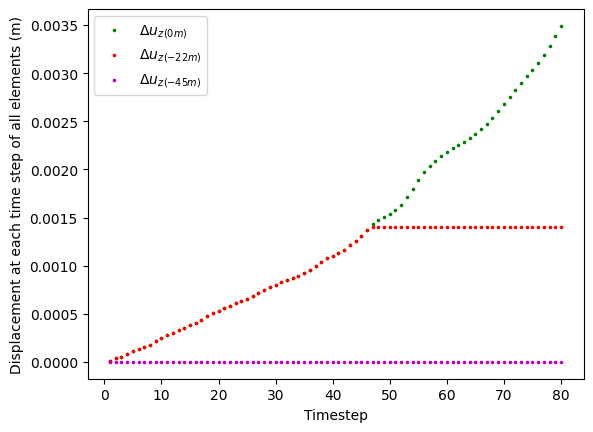

In [6]:
relative_pt0_displacement =displacement_linear["pt0"][1:, ax]-displacement_linear["pt0"][:-1, ax]
plt.scatter(time[1:], relative_pt0_displacement , s=10, c="g", marker= ".", label='$\Delta$$u$$_z$$_{('+ str(points["pt0"][ax])+ 'm)}$')

relative_pt1_displacement =displacement_linear["pt1"][1:, ax]-displacement_linear["pt1"][:-1, ax]
plt.scatter(time[1:], relative_pt1_displacement , s=10, c="r", marker= ".",  label='$\Delta$$u$$_z$$_{('+ str(points["pt1"][ax])+ 'm)}$')

relative_pt2_displacement = displacement_linear["pt2"][1:, ax]-displacement_linear["pt2"][:-1, ax]
plt.scatter(time[1:], relative_pt2_displacement , s=10, c="m", marker= ".", label='$\Delta$$u$$_z$$_{('+ str(points["pt2"][ax])+ 'm)}$')

#relative_pt3_displacement = displacement_linear["pt3"][1:, ax]-displacement_linear["pt3"][:-1, ax]
#plt.scatter(time[1:], relative_pt3_displacement, s=16 , c="b", marker= "x", label='$\Delta$$u$$_z$$_{('+ str(points["pt3"][ax])+ 'm)}$')

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Displacement at each time step of all elements (m)")

In [7]:
def compute_pts(relative_pt0_displacement):
    n = len(relative_pt0_displacement)
    pts = np.zeros(n)
    for i in range(n):
        pts[i] = relative_pt0_displacement[i] - 2 * np.sum(pts[:i])
    return pts

particular_u_at_timestep = compute_pts(relative_pt0_displacement)

Text(-10, 0.10904378189673954, '0.109')

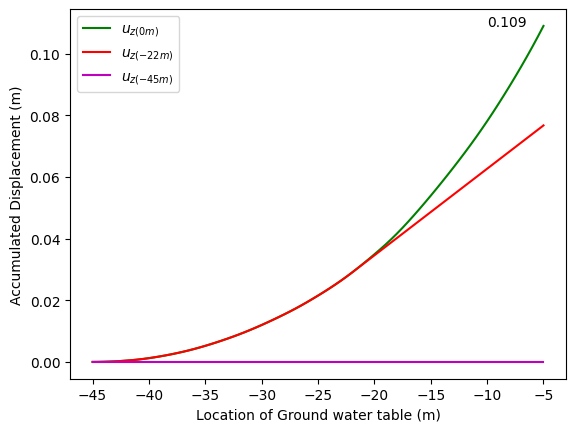

In [8]:
GWT = initial_GWT + time * delta_time

plt.plot(GWT, displacement_linear["pt0"][:, ax], "g-",  label="$u_{z(" + str(points["pt0"][ax]) + "m)}$")
plt.plot(GWT, displacement_linear["pt1"][:, ax], "r-", label="$u_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(GWT, displacement_linear["pt2"][:, ax], "m-", label="$u_{z(" + str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Location of Ground water table (m)")
plt.ylabel("Accumulated Displacement (m)")
last_data= displacement_linear["pt0"][-1, ax]
last_data_3decimal= "%.3f" % round(last_data, 3)
plt.annotate(str(last_data_3decimal),(-10, last_data))

In [9]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, "$\\sigma'_{yy}$ (Pa)")

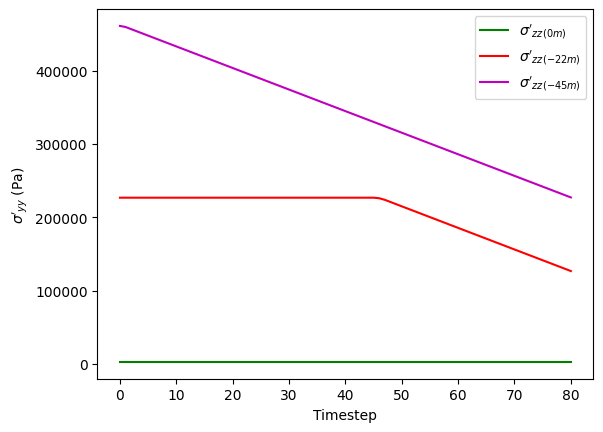

In [10]:
stress = pvdfile.read_time_series("sigma", points, interpolation_method="linear")
plt.plot(time, -stress["pt0"][:, ax], "g-",  label="$\sigma\'_{zz}$$_{("+ str(points["pt0"][ax])+ "m)}$")
plt.plot(time, -stress["pt1"][:, ax], "r-", label="$\sigma\'_{zz}$$_{("+ str(points["pt1"][ax])+ "m)}$")
plt.plot(time, -stress["pt2"][:, ax], "m-", label="$\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")
#plt.plot(time, -stress["pt3"][:, ax], "b-", label="$\sigma\'_{zz}$$_{("+ str(points["pt3"][ax])+ "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\sigma\'_{yy}$" + " (Pa)")

In [11]:
-stress["pt0"][:, 1]

array([2575.125       , 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2575.1250000981, 2575.1250000981, 2575.1250000981,
       2575.1250000981, 2

In [12]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, "$\\Delta\\sigma'_{zz}$ (Pa)")

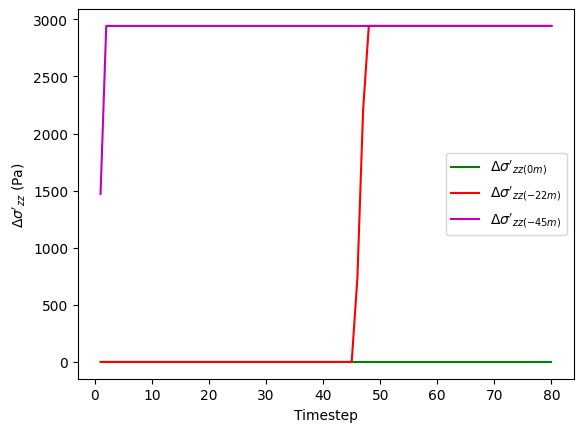

In [13]:
stress = pvdfile.read_time_series("sigma", points, interpolation_method="linear")

relative_pt0_stress = stress["pt0"][1:, ax]-stress["pt0"][:-1, ax]
plt.plot(time[1:], relative_pt0_stress, "g-",  label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt0"][ax])+ "m)}$")

relative_pt1_stress = stress["pt1"][1:, ax]-stress["pt1"][:-1, ax]
plt.plot(time[1:], relative_pt1_stress, "r-",  label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt1"][ax])+ "m)}$")

relative_pt2_stress = stress["pt2"][1:, ax]-stress["pt2"][:-1, ax]
plt.plot(time[1:], relative_pt2_stress, "m-", label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")

#relative_pt2_stress = stress["pt3"][1:, ax]-stress["pt2"][:-1, ax]
#plt.plot(time[1:], relative_pt2_stress, "b-", label="$\Delta\sigma\'_{zz}$$_{("+ str(points["pt3"][ax])+ "m)}$")


plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\Delta\sigma\'_{zz}$" + " (Pa)")

In [14]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Epsilon')

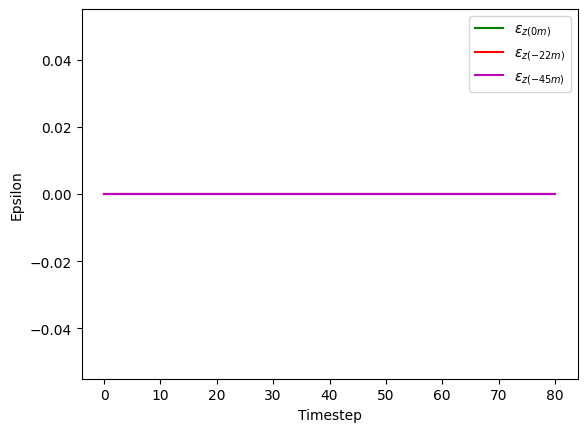

In [15]:
epsilon = pvdfile.read_time_series("epsilon", points, interpolation_method="linear")
plt.plot(time, epsilon ["pt0"][:, 2], "g-", label="$\epsilon_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time, epsilon ["pt1"][:, 2], "r-", label="$\epsilon_{z("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time, epsilon ["pt2"][:, 2], "m-", label="$\epsilon_{z("+ str(points["pt2"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Epsilon")

In [16]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Change in Epsilon')

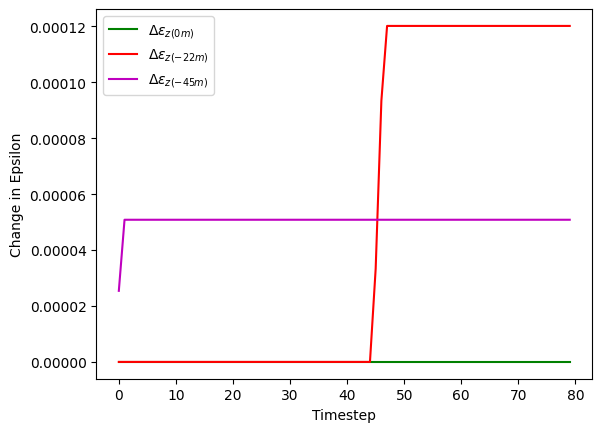

In [17]:
relative_pt0_epsilon = epsilon ["pt0"][1:, ax] - epsilon ["pt0"][:-1, ax]
relative_pt1_epsilon = epsilon ["pt1"][1:, ax] - epsilon ["pt1"][:-1, ax]
relative_pt2_epsilon = epsilon ["pt2"][1:, ax] - epsilon ["pt2"][:-1, ax]
#relative_pt3_epsilon = epsilon ["pt3"][1:, ax] - epsilon ["pt3"][:-1, ax]


plt.plot(time[:-1], relative_pt0_epsilon, "g-", label="$\Delta\epsilon_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt1_epsilon, "r-", label="$\Delta\epsilon_{z("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt2_epsilon, "m-", label="$\Delta\epsilon_{z("+ str(points["pt2"][ax]) + "m)}$")
#plt.plot(time[:-1], relative_pt3_epsilon, "m-", label="$\Delta\epsilon_{z("+ str(points["pt3"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Change in Epsilon")

In [18]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

Text(0, 0.5, 'Pore pressure (Pa)')

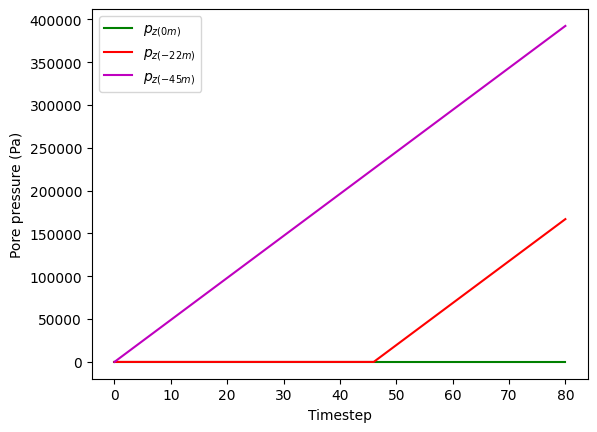

In [19]:
pore_pressure = pvdfile.read_time_series("pressure", points, interpolation_method="linear")
plt.plot(time, pore_pressure ["pt0"], "g-", label="$p_{z("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time, pore_pressure ["pt1"], "r-", label="$p_{z(" + str(points["pt1"][ax]) + "m)}$")
plt.plot(time, pore_pressure ["pt2"], "m-", label="$p_{z("+ str(points["pt2"][ax]) + "m)}$")
#plt.plot(time, pore_pressure ["pt3"], "m-", label="$p_{z("+ str(points["pt3"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Pore pressure (Pa)")

Text(0, 0.5, 'Change in pore pressure (Pa)')

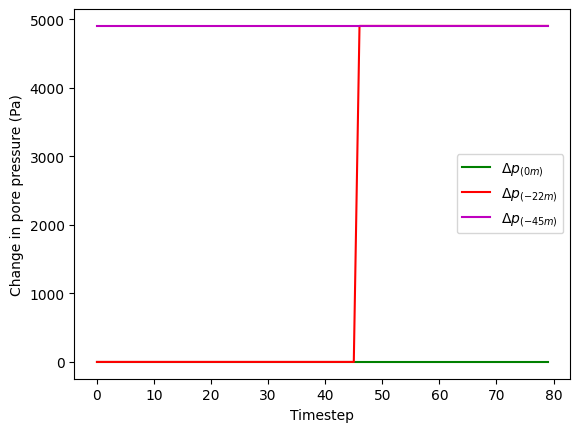

In [20]:
relative_pt0_pore_pressure = pore_pressure ["pt0"][1:] - pore_pressure ["pt0"][:-1]
relative_pt1_pore_pressure = pore_pressure ["pt1"][1:] - pore_pressure ["pt1"][:-1]
relative_pt2_pore_pressure = pore_pressure ["pt2"][1:] - pore_pressure ["pt2"][:-1]
#relative_pt3_pore_pressure = pore_pressure ["pt3"][1:] - pore_pressure ["pt3"][:-1]

plt.plot(time[:-1], relative_pt0_pore_pressure , "g-", label="$\Delta p_{("+ str(points["pt0"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt1_pore_pressure , "r-", label="$\Delta p_{("+ str(points["pt1"][ax]) + "m)}$")
plt.plot(time[:-1], relative_pt2_pore_pressure , "m-", label="$\Delta p_{("+ str(points["pt2"][ax]) + "m)}$")
#plt.plot(time[:-1], relative_pt3_pore_pressure , "b-", label="$\Delta p_{("+ str(points["pt3"][ax]) + "m)}$")

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("Change in pore pressure (Pa)")

Text(0, 0.5, '$\\sigma$$_{zz}$ (Pa)')

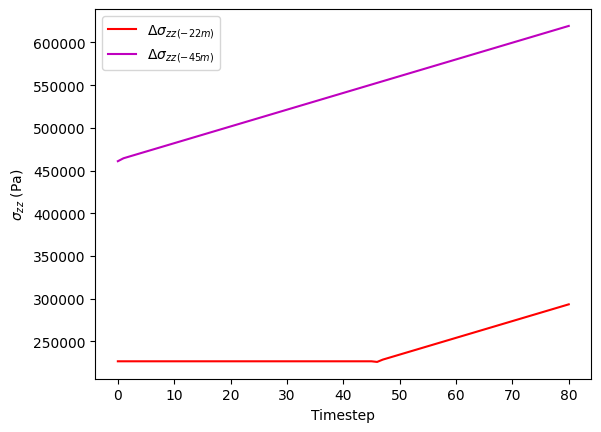

In [21]:
totalstress_pt0 = -stress["pt0"][:, 1] + pore_pressure["pt0"]
totalstress_pt1 = -stress["pt1"][:, 1] + pore_pressure["pt1"]
totalstress_pt2 = -stress["pt2"][:, 1] + pore_pressure["pt2"]
#totalstress_pt3 = -stress["pt3"][:, 1] + pore_pressure["pt3"]

#plt.plot(time, totalstress_pt0 , "g-", label="$totalstress_{zz("+ str(points["pt0"][1]) + "m)}$")
plt.plot(time, totalstress_pt1 , "r-", label='$\Delta\sigma$$_{zz}$$_{('+ str(points["pt1"][ax])+ 'm)}$')
plt.plot(time, totalstress_pt2 , "m-", label='$\Delta\sigma$$_{zz}$$_{('+ str(points["pt2"][ax])+ 'm)}$')
#plt.plot(time, totalstress_pt3 , "b-", label='$\Delta\sigma$$_{zz}$$_{('+ str(points["pt3"][ax])+ 'm)}$')

plt.legend()
plt.xlabel("Timestep")
plt.ylabel("$\sigma$$_{zz}$" + ' (Pa)')

In [22]:
plt.close

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

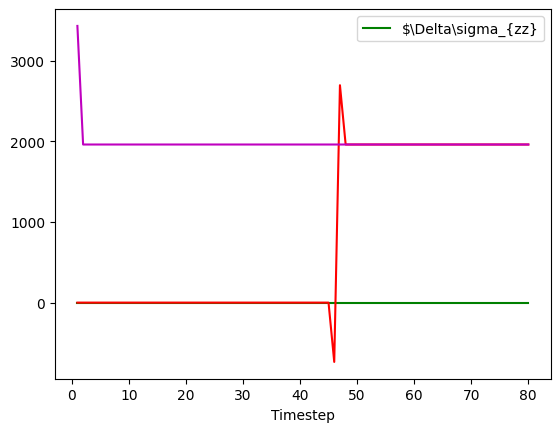

In [23]:
relative_pt0_totalstress = totalstress_pt0[1:] - totalstress_pt0[:-1]
relative_pt1_totalstress = totalstress_pt1[1:] - totalstress_pt1[:-1]
relative_pt2_totalstress = totalstress_pt2[1:] - totalstress_pt2[:-1]
#relative_pt3_totalstress = totalstress_pt3[1:] - totalstress_pt3[:-1]

plt.plot(time[1:], relative_pt0_totalstress , "g-", label="$\Delta\sigma_{zz}")

plt.legend()
plt.xlabel("Timestep")
#plt.ylabel("$\Delta$$\sigma$$_{zz}$")$$_{("+ str(points["pt0"][ax])+ "m)})
plt.plot(time[1:], relative_pt1_totalstress , "r-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt1"][ax])+ "m)}$")
plt.plot(time[1:], relative_pt2_totalstress , "m-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt2"][ax])+ "m)}$")
#plt.plot(time[1:], relative_pt3_totalstress , "b-", label="$\Delta\sigma_{zz}$$_{("+ str(points["pt3"][ax])+ "m)}$")


In [24]:
os.chdir('..')